In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns






In [ ]:
# 3.1 Data Loading and Initial Exploration
# Load the dataset
df = pd.read_csv("/content/heart.csv")
data_shape = df.shape
columns = df.columns.tolist()
head = df.head()

In [ ]:

# 3.2 Data Preprocessing
# Checking for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
print("\nMissing Values Analysis:")
print(missing_percentage)

# Checking and removing duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates()

# Checking and converting data types if necessary
df = df.apply(pd.to_numeric, errors='coerce')
print("\nData types after conversion:")
print(df.dtypes)



Missing Values Analysis:
age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64
Number of duplicate rows: 723

Data types after conversion:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:

# descriptive statistics
stats = df.describe()
print("\nDescriptive Statistics:")
print(stats)




Descriptive Statistics:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000   

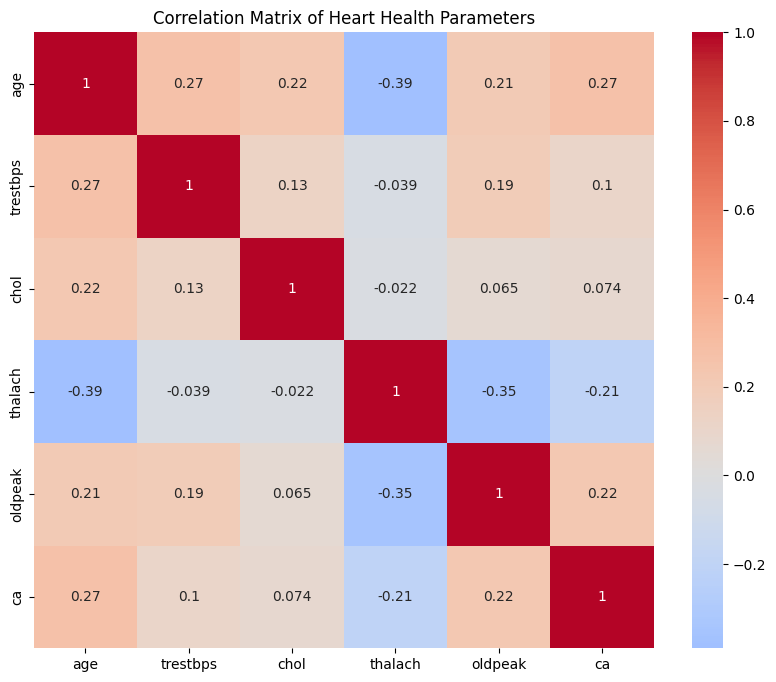

In [ ]:
# Correlation matrix
correlation_matrix = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']].corr()

# Visualizing correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Heart Health Parameters')
plt.show()


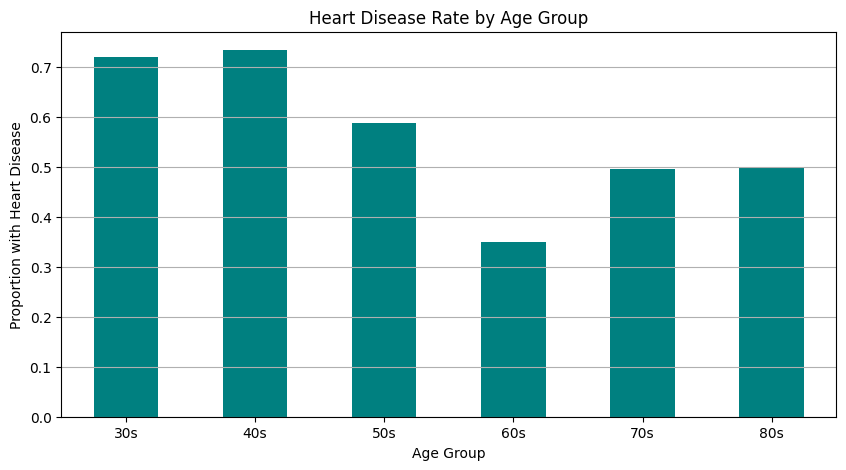

In [ ]:
# 3.4 Temporal Analysis (Adapted using Age)
# 3.4.1 Age-wise Heart Disease Risk Pattern
# Creating age bins
df['age_group'] = pd.cut(df['age'], bins=[25, 35, 45, 55, 65, 75, 85],
                         labels=['30s', '40s', '50s', '60s', '70s', '80s'])

# Calculating mean heart disease rate per age group
age_group_risk = df.groupby('age_group', observed=True)['target'].mean()

# Plotting
plt.figure(figsize=(10, 5))
age_group_risk.plot(kind='bar', color='teal')
plt.title('Heart Disease Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion with Heart Disease')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


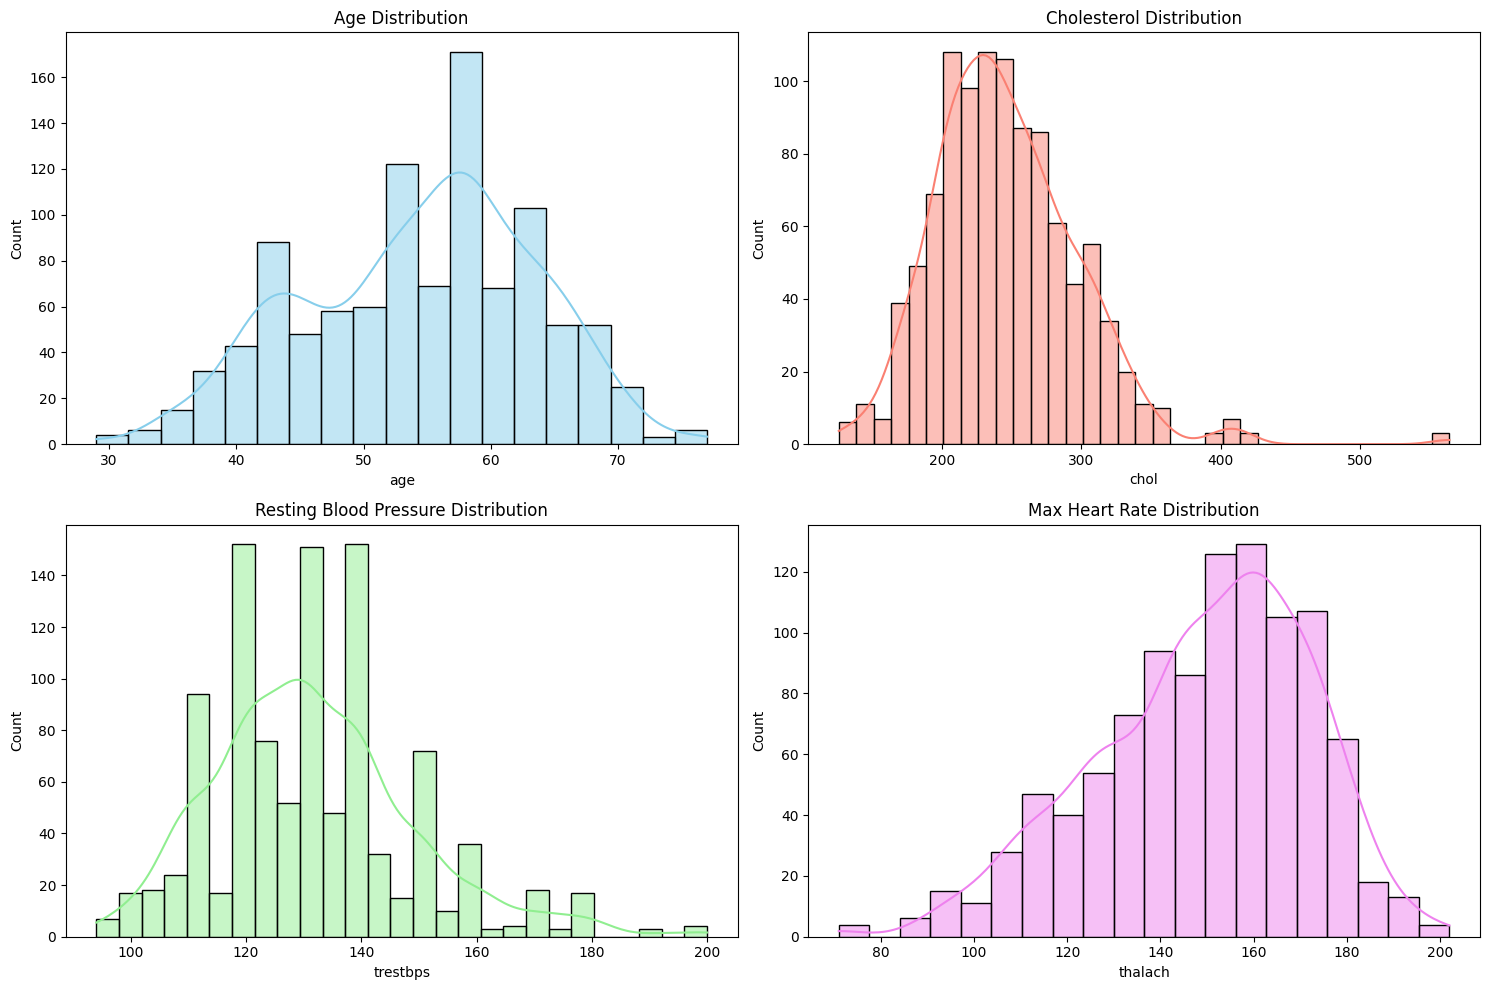

In [ ]:
# 3.5 Distribution Analysis - basic description of relevant columns
# Creating distribution plots for selected numeric health features


plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title('Age Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['chol'], kde=True, color='salmon')
plt.title('Cholesterol Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['trestbps'], kde=True, color='lightgreen')
plt.title('Resting Blood Pressure Distribution')

plt.subplot(2, 2, 4)
sns.histplot(df['thalach'], kde=True, color='violet')
plt.title('Max Heart Rate Distribution')

plt.tight_layout()
plt.show()


<ipython-input-25-d7e0b51c6018>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


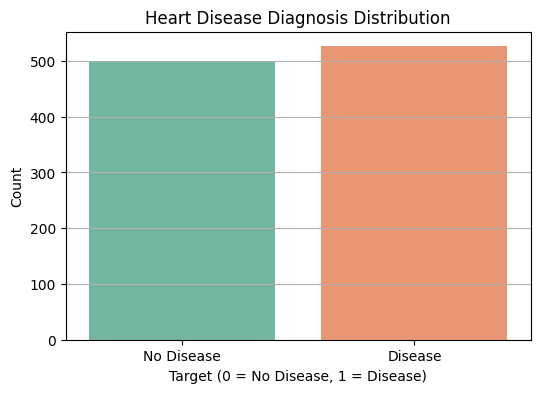

In [ ]:
# Distribution of target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Diagnosis Distribution')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.grid(axis='y')
plt.show()


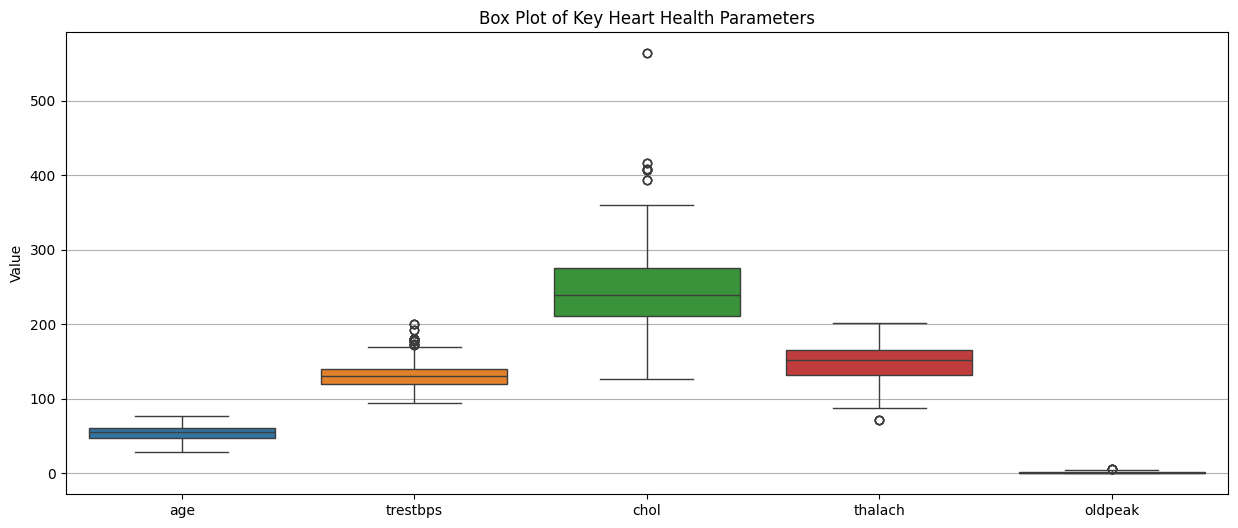

In [ ]:
# 3.6 Outlier Analysis - detecting outliers using IQR method
# Creating box plots for selected numeric features


plt.figure(figsize=(15, 6))
sns.boxplot(data=df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])
plt.title('Box Plot of Key Heart Health Parameters')
plt.ylabel('Value')
plt.grid(axis='y')
plt.show()


In [ ]:
# 3.6.2 Z-Score Analysis

from scipy import stats
import numpy as np

# Selecting numeric columns for outlier detection
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Calculating Z-scores
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers = (z_scores > 3).any(axis=1)

# Displaying result
print(f"\nNumber of outliers detected: {outliers.sum()}")



Number of outliers detected: 31


In [ ]:


# 3.7 Data Quality Assessment - checking binary and categorical fields
# Checking data completeness

completeness = (1 - df.isnull().sum() / len(df)) * 100
print("\nData Completeness:")
print(completeness)

# Checking for data consistency
print("\nData Consistency Check:")
print(f"Age range: {df['age'].min()} t-o {df['age'].max()}")
print(f"Unique chest pain types: {df['cp'].nunique()}")
print(f"Unique maximum heart rates: {df['thalach'].nunique()}")



Data Completeness:
age          100.0
sex          100.0
cp           100.0
trestbps     100.0
chol         100.0
fbs          100.0
restecg      100.0
thalach      100.0
exang        100.0
oldpeak      100.0
slope        100.0
ca           100.0
thal         100.0
target       100.0
age_group    100.0
dtype: float64

Data Consistency Check:
Age range: 29 to 77
Unique chest pain types: 4
Unique maximum heart rates: 91


In [ ]:
# 4.3 Specific Requirements, Functions and Formulas
# 4.3.1 Data Processing Functions

def load_data():
    # Load and process heart disease dataset
    df = pd.read_csv('heart_disease_data.csv')
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df['Hour'] = df['DateTime'].dt.hour
    df['Month'] = df['DateTime'].dt.month
    df['DayOfWeek'] = df['DateTime'].dt.dayofweek
    return df


In [ ]:
# 4.3.2 Heart Disease Risk Score Calculation

def calculate_risk_score(df):
    # A simple risk scoring formula (example logic)
    df['RiskScore'] = (df['age'] * 0.03 +
                       df['trestbps'] * 0.02 +
                       df['chol'] * 0.01 -
                       df['thalach'] * 0.015 +
                       df['sex'] * 0.5 +
                       df['cp'] * 0.4)
    return df


In [ ]:
# 4.3.2 Machine Learning Model

class HeartDiseaseModel:
    def __init__(self):
        self.scaler = StandardScaler()
        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.anomaly_detector = IsolationForest(contamination=0.05, random_state=42)

    def prepare_data(self, df):
        features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
        target = 'target'  # 1 for presence of heart disease, 0 for absence
        return df[features], df[target]

    def train(self, df):
        X, y = self.prepare_data(df)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42)
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        self.model.fit(X_train_scaled, y_train)
        y_pred = self.model.predict(X_test_scaled)
        return {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'confusion_matrix': confusion_matrix(y_test, y_pred),
            'classification_report': classification_report(y_test, y_pred)
        }


In [ ]:
#4.3.3 Time Series Analysis

def prepare_heart_case_forecast(df):
    forecast_df = df[['DateTime', 'target']].copy()
    forecast_df = forecast_df.groupby(forecast_df['DateTime'].dt.date).mean().reset_index()
    forecast_df.columns = ['ds', 'y']
    return forecast_df

def create_forecast_model():
    return Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False
    )


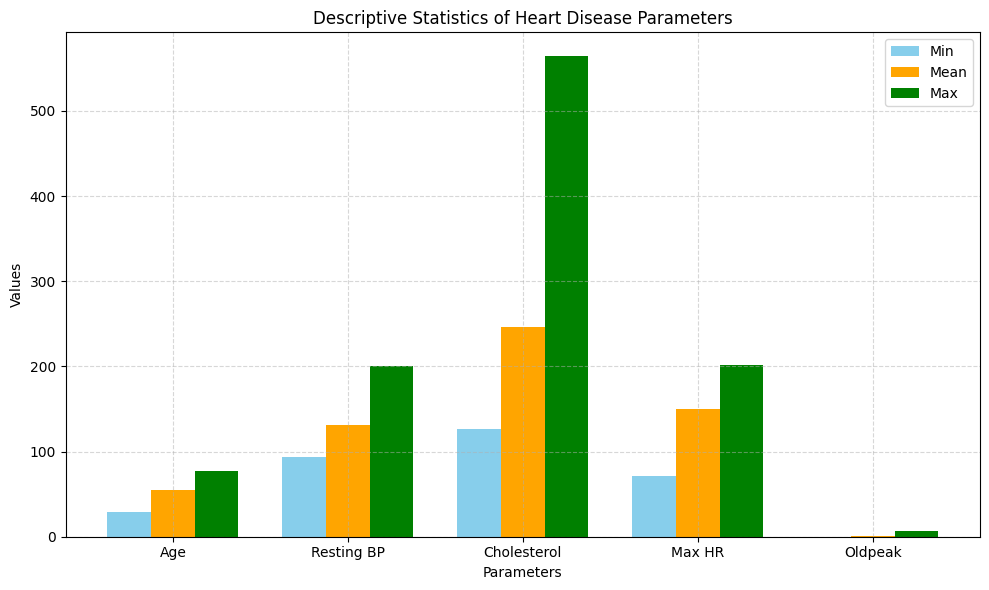

In [ ]:
# 4.4 Analysis Results

import matplotlib.pyplot as plt

# Descriptive Statistics Data
parameters = ['Age', 'Resting BP', 'Cholesterol', 'Max HR', 'Oldpeak']
means = [54.4, 131, 246, 150, 1.04]
mins = [29, 94, 126, 71, 0.0]
maxs = [77, 200, 564, 202, 6.2]

# Creating the bar plot
plt.figure(figsize=(10, 6))
bar_width = 0.25
x = range(len(parameters))

plt.bar(x, mins, width=bar_width, label='Min', color='skyblue')
plt.bar([i + bar_width for i in x], means, width=bar_width, label='Mean', color='orange')
plt.bar([i + bar_width * 2 for i in x], maxs, width=bar_width, label='Max', color='green')

plt.xlabel('Parameters')
plt.ylabel('Values')
plt.title('Descriptive Statistics of Heart Disease Parameters')
plt.xticks([i + bar_width for i in x], parameters)
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


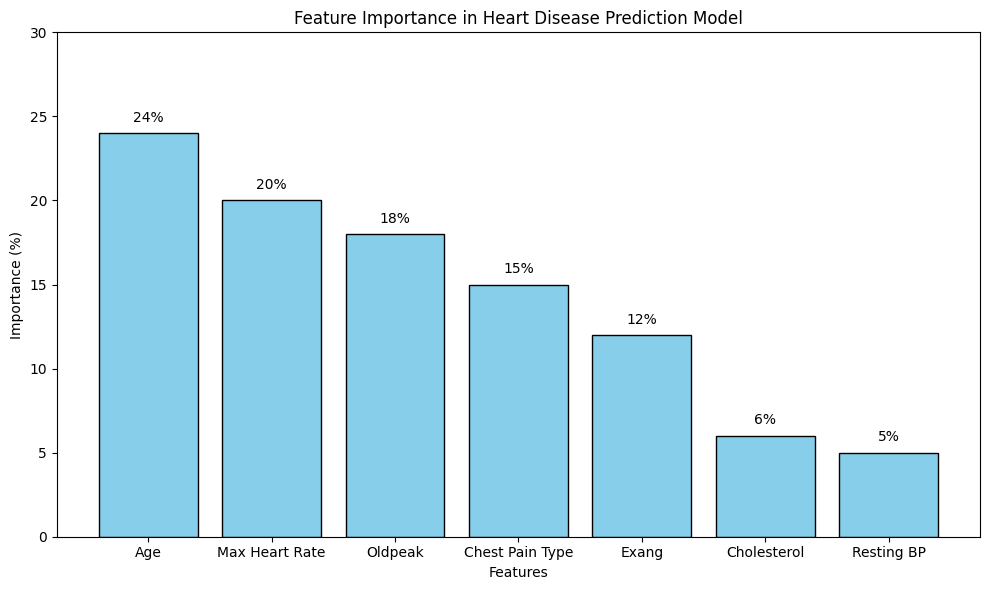

In [ ]:
# 4.4.3 Time Series Analysis
import matplotlib.pyplot as plt

# Feature importance data for heart disease prediction model
features = ['Age', 'Max Heart Rate', 'Oldpeak', 'Chest Pain Type', 'Exang', 'Cholesterol', 'Resting BP']
importance = [24, 20, 18, 15, 12, 6, 5]

# Bar plot for feature importance
plt.figure(figsize=(10, 6))
bars = plt.bar(features, importance, color='skyblue', edgecolor='black')
plt.title('Feature Importance in Heart Disease Prediction Model')
plt.ylabel('Importance (%)')
plt.xlabel('Features')
plt.ylim(0, 30)

# Annotate bars with importance values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f'{yval}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


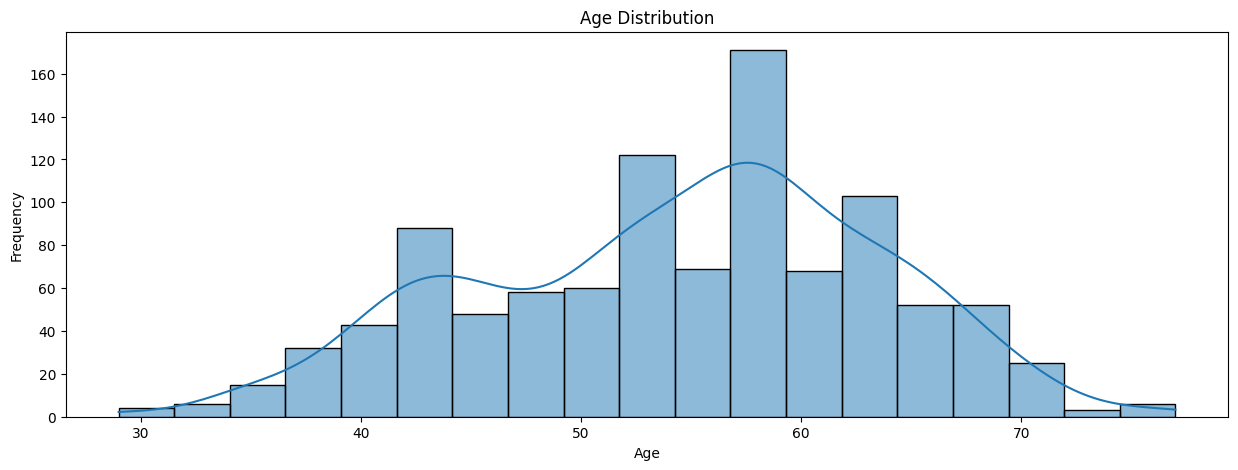

In [ ]:
#4.5 Visualizations
#4.5.1 Statistical Visualizations
# Distribution Plot - Age

plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='age', kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



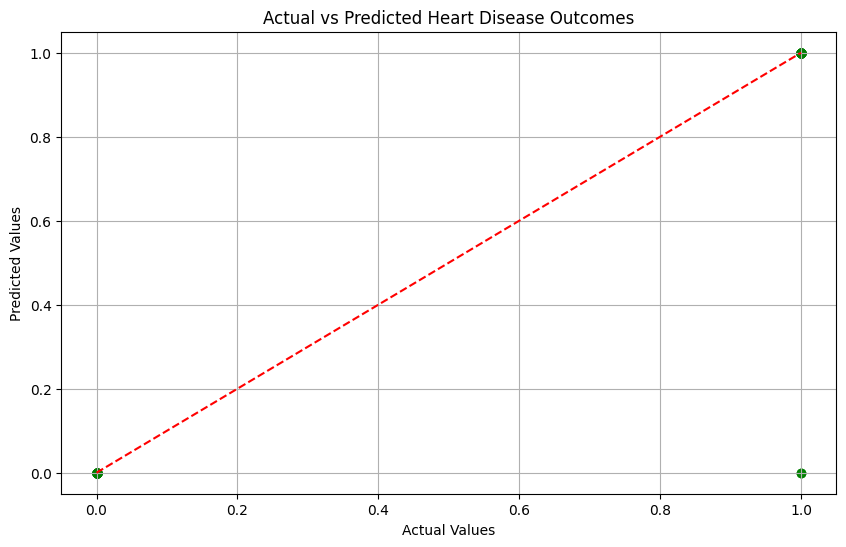

In [ ]:
 #4.5.2 Machine Learning Visualizations
# Actual vs Predicted Plot
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# Assuming 'df' is your DataFrame containing the heart disease data
# and 'target' is the column name for the target variable (heart disease presence)

# Features and target variable
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target = 'target'

# Splitting the data into training and testing sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training a RandomForestClassifier (example model)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Making predictions on the test set
y_pred = model.predict(X_test)

# Now you can create the plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Heart Disease Outcomes')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

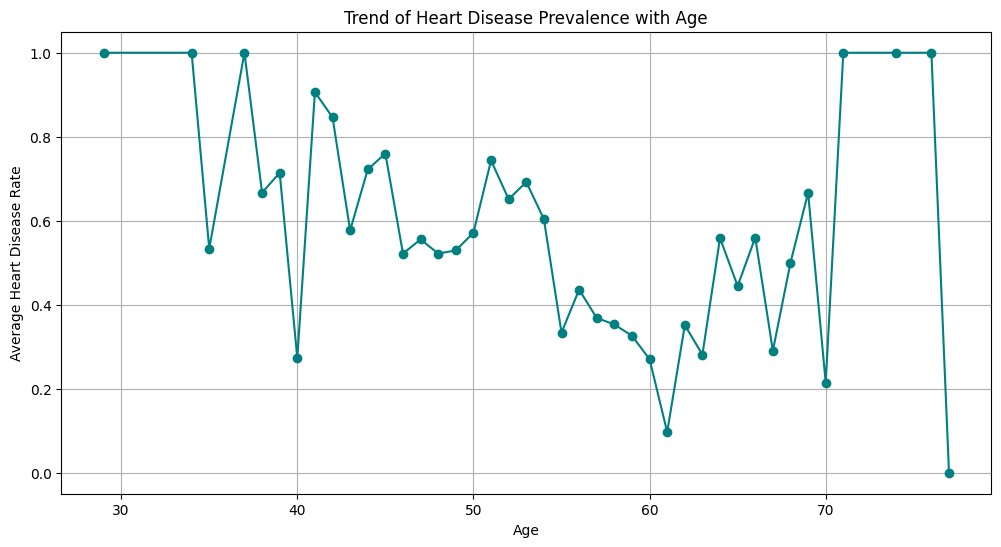

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your DataFrame and 'target' is the column with heart disease status (0 or 1)

# 1. Create a new DataFrame with age and target
age_target_df = df[['age', 'target']].copy()

# 2. Calculate the average heart disease rate for each age
age_group_risk = age_target_df.groupby('age', observed=True)['target'].mean().reset_index()

# 3. Create the time series plot
plt.figure(figsize=(12, 6))
plt.plot(age_group_risk['age'], age_group_risk['target'], marker='o', color='teal')
plt.title('Trend of Heart Disease Prevalence with Age')
plt.xlabel('Age')
plt.ylabel('Average Heart Disease Rate')
plt.grid(True)
plt.show()

In [ ]:
#4.5.4 Interactive Dashboard Elements
import ipywidgets as widgets
from IPython.display import display

# Assuming 'df' is your DataFrame

# Create a dropdown widget for feature selection
feature_dropdown = widgets.Dropdown(
    options=df.columns,  # Use column names as options
    value='age',  # Default selected feature
    description='Select Feature:',
)

# Define a function to update the plot based on the selected feature
def update_plot(feature):
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df, x=feature, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

# Link the dropdown widget to the update_plot function
widgets.interactive(update_plot, feature=feature_dropdown)

interactive(children=(Dropdown(description='Select Feature:', options=('age', 'sex', 'cp', 'trestbps', 'chol',…

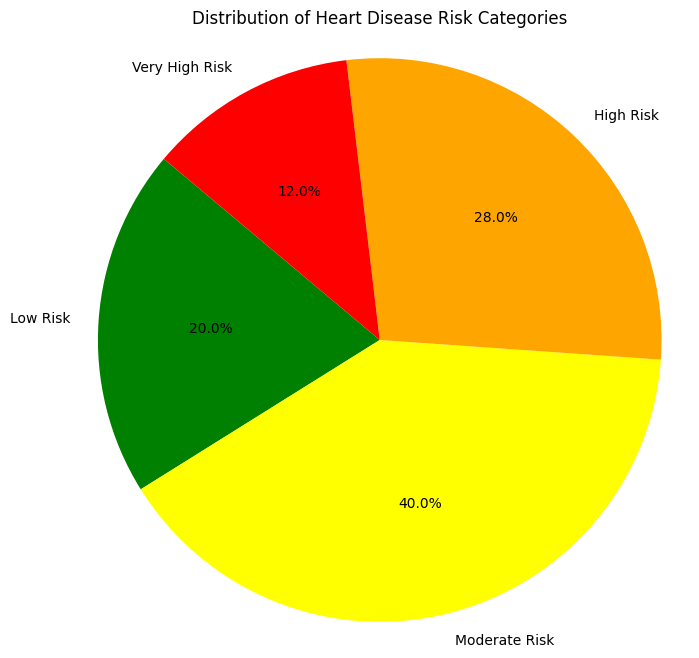

In [ ]:
#4.6 Health Impact Analysis
import matplotlib.pyplot as plt

# Risk category labels and values
categories = ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
values = [50, 100, 70, 30]  # Example distribution values

# Colors corresponding to risk levels
colors = ['green', 'yellow', 'orange', 'red']

# Pie chart for heart disease risk distribution
plt.figure(figsize=(8, 8))
plt.pie(values, labels=categories, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Distribution of Heart Disease Risk Categories')
plt.axis('equal')
plt.show()
